# Do not forget to try knn derived featrues (distances to the classes as a features)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


Merged compounds (CID overlap): n = 312
Features in block: 54

All features ranked by |r| with Imax (Pearson):
                                 r_vs_Imax
f1_mass_PC1                      -0.594668
f7_surface_shape_Mor_PC2         -0.587288
f6_volume_PC1                    -0.545686
f4_volume_PC1                    -0.518726
f8_surface_shape_RDF_PC1         -0.508949
f5_volume_PC1                    -0.498108
f10_geometry_topology_PC1        -0.478887
f9_whim_PC1                      -0.477962
f14_spdiam_PC1                   -0.462750
f13_p_vsa_logp_PC5               -0.452434
f3_lipophilicity_extended_PC1    -0.380323
f2_lipophilicity_PC1             -0.368009
f13_p_vsa_logp_PC3               -0.342908
f11_spatial_autocorrelation_PC3   0.328998
f12_polarity_PC1                 -0.284340
f14_spdiam_PC3                   -0.260563
f10_geometry_topology_PC3        -0.243415
f14_spdiam_PC2                   -0.239374
f10_geometry_topology_PC4        -0.207136
f11_spatial_autocorrelation_P

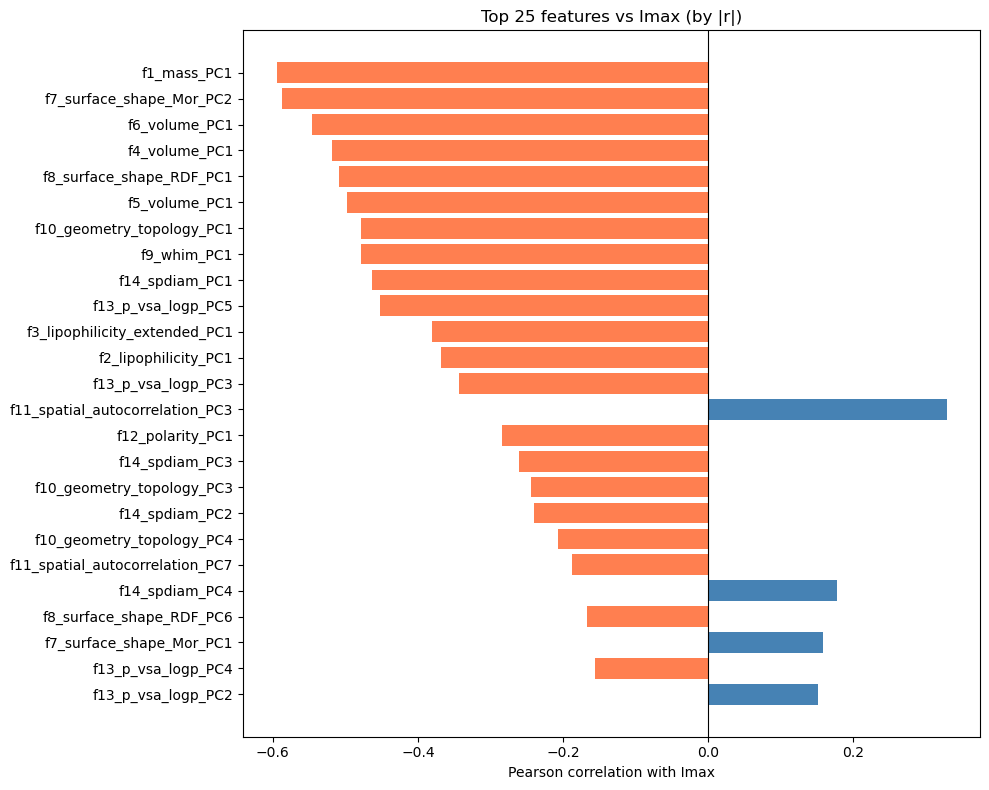

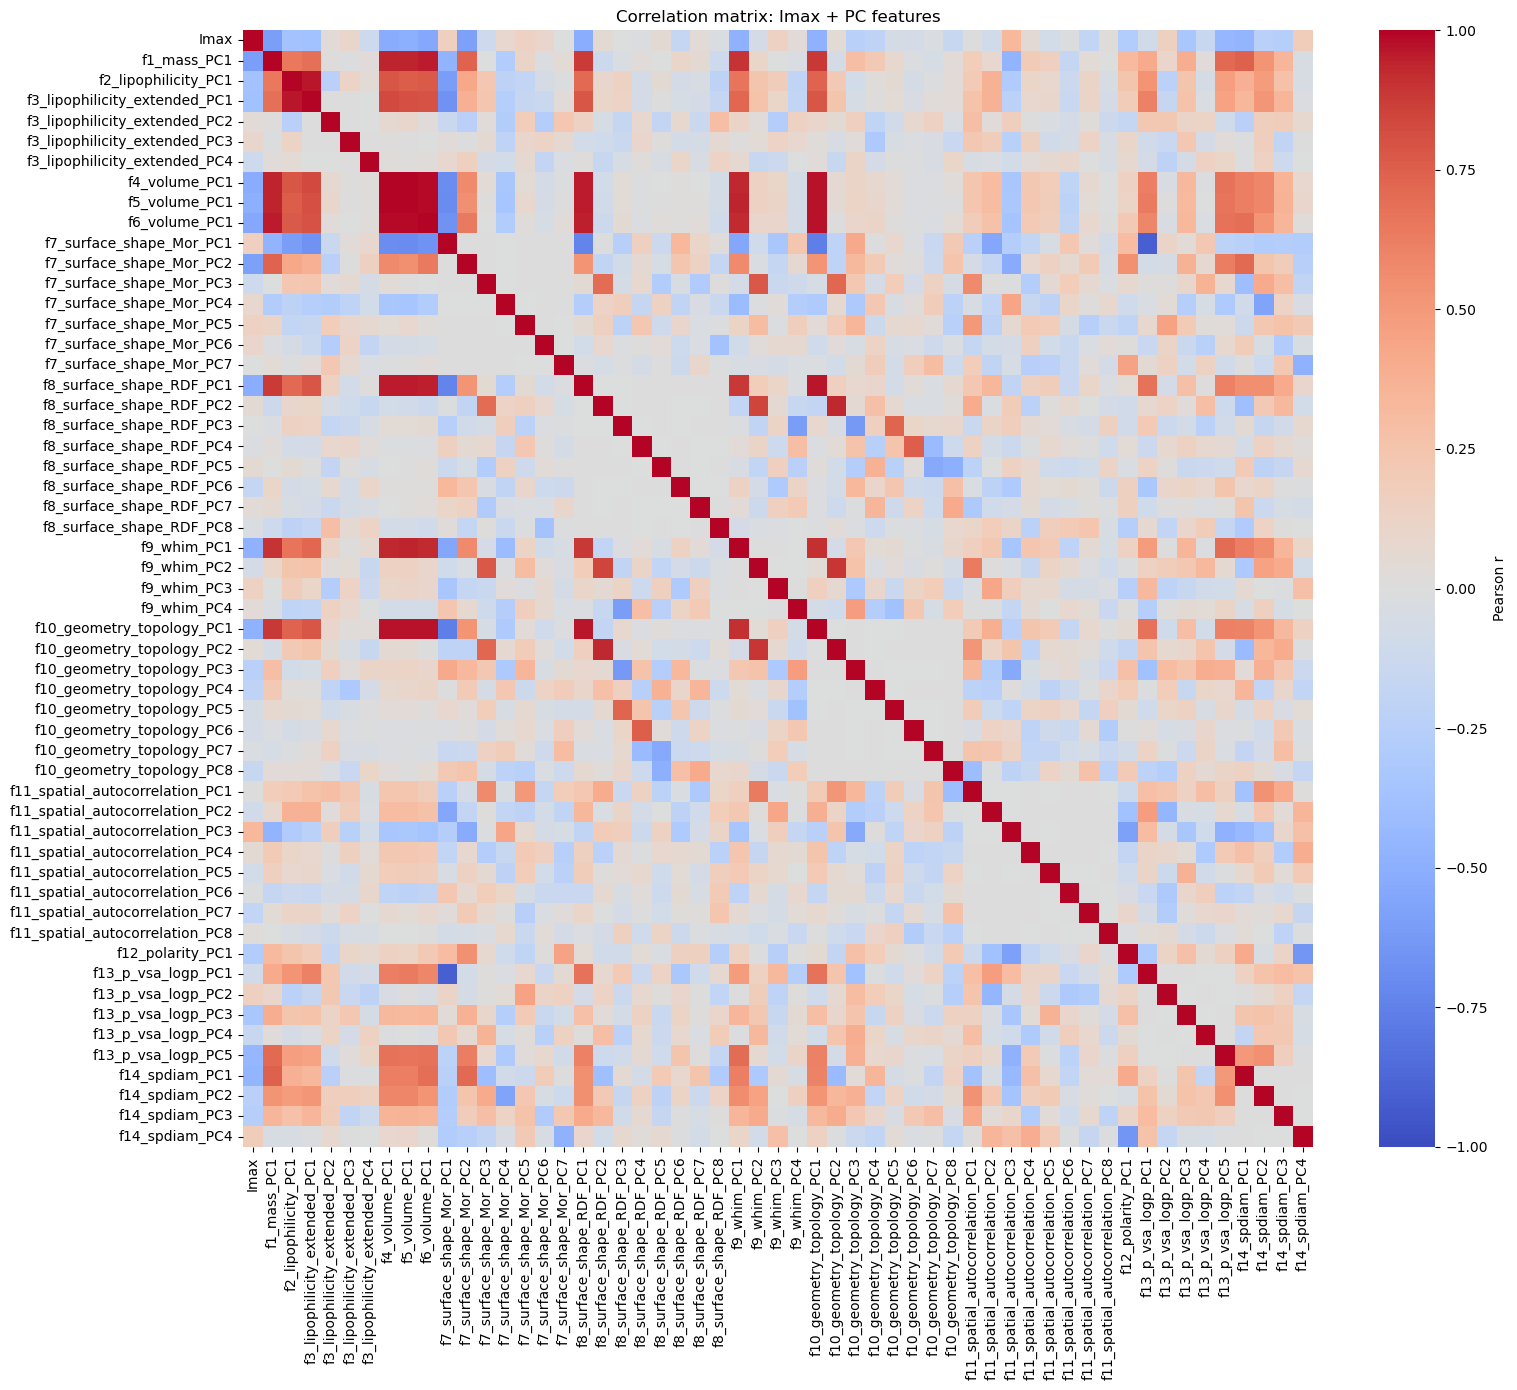

In [2]:
# Pearson correlation: Imax vs all engineered features (from f1_mass_PC1 onward).
# Rows are aligned by CID between odor data and the saved feature matrix.

START_FEAT = "f1_mass_PC1"

data_df = pd.read_csv("data/waka_dragon_merged.csv")
features_df = pd.read_csv("data/features_df_v1.csv")

if START_FEAT not in features_df.columns:
    raise KeyError(f"{START_FEAT!r} not in features_df.columns")

feat_block = features_df.loc[:, START_FEAT:]
merged = data_df[["CID", "Imax"]].merge(
    pd.concat([features_df[["CID"]], feat_block], axis=1),
    on="CID",
    how="inner",
)

cols = ["Imax"] + list(feat_block.columns)
corr_matrix = merged[cols].corr()

imax_corr = corr_matrix["Imax"].drop("Imax")
imax_corr = imax_corr.reindex(imax_corr.abs().sort_values(ascending=False).index)

print(f"Merged compounds (CID overlap): n = {len(merged)}")
print(f"Features in block: {feat_block.shape[1]}")
print("\nAll features ranked by |r| with Imax (Pearson):")
print(imax_corr.to_frame("r_vs_Imax").to_string())

# Bar chart: top 25 by |r|
top_k = 25
top = imax_corr.head(top_k)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(top.index[::-1], top.values[::-1], color=np.where(top.values[::-1] >= 0, "steelblue", "coral"))
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Pearson correlation with Imax")
ax.set_title(f"Top {top_k} features vs Imax (by |r|)")
plt.tight_layout()
plt.show()

# Full correlation heatmap (Imax + all features)
if sns is not None:
    fig2, ax2 = plt.subplots(figsize=(16, 14))
    sns.heatmap(
        corr_matrix,
        cmap="coolwarm",
        center=0,
        vmin=-1,
        vmax=1,
        square=False,
        cbar_kws={"label": "Pearson r"},
        ax=ax2,
    )
    ax2.set_title("Correlation matrix: Imax + PC features")
    plt.tight_layout()
    plt.show()
else:
    fig2, ax2 = plt.subplots(figsize=(16, 14))
    im = ax2.imshow(corr_matrix.values, cmap="coolwarm", vmin=-1, vmax=1, aspect="auto")
    ax2.set_xticks(range(len(corr_matrix.columns)))
    ax2.set_xticklabels(corr_matrix.columns, rotation=90, fontsize=6)
    ax2.set_yticks(range(len(corr_matrix.index)))
    ax2.set_yticklabels(corr_matrix.index, fontsize=6)
    plt.colorbar(im, ax=ax2, label="Pearson r")
    ax2.set_title("Correlation matrix: Imax + PC features (install seaborn for nicer labels)")
    plt.tight_layout()
    plt.show()

In [3]:
# Top 10 features by |Pearson r| with Imax (run after merged / imax_corr exist)
TOP_N = 10
top_feature_names = imax_corr.head(TOP_N).index.tolist()

In [4]:
# Feature matrix: columns = descriptor names
X_top_df = merged[top_feature_names].copy()
# NumPy array for sklearn / further analysis (same row order as merged)
X_top_arr = X_top_df.to_numpy(dtype=float)
print("Selected columns:", top_feature_names)
print("DataFrame:", X_top_df.shape, "| ndarray:", X_top_arr.shape)

Selected columns: ['f1_mass_PC1', 'f7_surface_shape_Mor_PC2', 'f6_volume_PC1', 'f4_volume_PC1', 'f8_surface_shape_RDF_PC1', 'f5_volume_PC1', 'f10_geometry_topology_PC1', 'f9_whim_PC1', 'f14_spdiam_PC1', 'f13_p_vsa_logp_PC5']
DataFrame: (312, 10) | ndarray: (312, 10)


In [5]:
# Import Packages

# General tools
import numpy as np
import pandas as pd


# Machine learning tools
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier

# Visualization tools
import matplotlib.pyplot as plt
from ipywidgets import interact, Dropdown, IntSlider

# Typing
from typing import Callable, Dict, List, Optional, Set, Tuple, Union
from numpy.typing import NDArray


In [6]:
# Parameters
numGridPts = 250

In [7]:
features_df = pd.read_csv('data/features_df_v1.csv')
features_df.head()


,Unnamed: 0,CID,f1_mass_PC1,f2_lipophilicity_PC1,f3_lipophilicity_extended_PC1,f3_lipophilicity_extended_PC2,f3_lipophilicity_extended_PC3,f3_lipophilicity_extended_PC4,f4_volume_PC1,f5_volume_PC1,...,f12_polarity_PC1,f13_p_vsa_logp_PC1,f13_p_vsa_logp_PC2,f13_p_vsa_logp_PC3,f13_p_vsa_logp_PC4,f13_p_vsa_logp_PC5,f14_spdiam_PC1,f14_spdiam_PC2,f14_spdiam_PC3,f14_spdiam_PC4
0,0,179,-2.286230,-3.199504,-4.752108,0.272682,-1.495469,-0.043973,-2.330895,-2.267296,...,-3.266010,-1.709109,-0.651472,-1.769849,0.042363,-0.585560,-2.207576,-1.116572,-1.030991,0.224150
1,1,240,-1.785254,-0.905835,-2.048200,-0.173442,-0.012213,0.073501,-1.940071,-1.974537,...,1.311706,-2.234276,0.148197,-1.827311,0.561739,-0.324015,-1.478688,-0.873687,-0.965321,-0.331766
2,2,244,-1.729065,-1.110483,-2.498396,-0.262601,-0.143003,0.135432,-1.807131,-1.909753,...,0.110622,-2.565265,-2.724089,-0.667275,0.541062,-0.392053,-1.478688,-0.873687,-0.965321,-0.331766
3,3,323,-0.672035,-0.335579,-1.273646,-0.440255,0.069105,0.099189,-1.355991,-1.277856,...,2.784734,-2.980042,0.105131,0.352292,0.253342,-0.257952,0.145131,-0.468554,-1.085965,-0.530584
4,4,326,-0.614455,0.190988,0.082531,-0.153126,0.156950,0.008979,-0.633067,-0.700927,...,0.835805,-1.540803,0.380345,-1.250471,0.003374,0.332070,-0.104281,-0.199312,-0.716612,-0.227728


In [8]:
data_df = pd.read_csv('data/waka_dragon_merged.csv')
data_df.head()

,Unnamed: 0.1,Unnamed: 0,CID,CAS,Name,Imax,Ci,Di_x,intensity_class,MW,...,VvdwMG,VvdwZAZ,PDI,BLTF96,BLTD48,BLTA96,nCIR,ZM1,R8u_,nRCOSR
0,12,12,179,513-86-0,acetoin,49.69,0.90,0.76,1,88.12,...,54.205,92.70,0.717,-1.20,-1.11,-1.00,0.0,22.0,0.000,0.0
1,40,40,240,100-52-7,benzaldehyde,62.02,1.23,0.69,1,106.13,...,62.810,104.63,0.919,-2.89,-3.00,-3.00,1.0,34.0,0.000,0.0
2,42,42,244,100-51-6,benzyl alcohol,30.28,1.49,0.33,0,108.15,...,65.737,107.27,0.866,-2.74,-2.83,-2.82,1.0,34.0,0.000,0.0
3,89,89,323,91-64-5,coumarin,26.79,0.68,0.77,0,146.15,...,75.670,133.02,0.984,-3.32,-3.47,-3.49,3.0,56.0,0.000,0.0
4,90,90,326,122-03-2,cumin aldehyde,49.53,1.29,0.47,1,148.22,...,91.587,156.53,0.898,-3.70,-3.91,-3.95,1.0,50.0,0.033,0.0


In [9]:
mX = features_df.loc[:, "f1_mass_PC1":].values
print(f'The shape of the feature matrix is {mX.shape}')

The shape of the feature matrix is (312, 54)


In [10]:

vY = data_df['Imax'].values
vY = np.where(vY >= 35, 1, 0)
print(f'The shape of labels matrix is {vY.shape}')
np.unique(vY, return_counts=True)


The shape of labels matrix is (312,)


(array([0, 1]), array([122, 190]))

In [11]:
# just for visualization purposes i want have the reduced dimension for mX to 2
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
mX_pca = pca.fit_transform(mX)

In [12]:
oSVC_clf = SVC(C=1, kernel='rbf', gamma=1).fit(mX, vY)
oSVC_clf.score(mX, vY)

0.9711538461538461

In [15]:
# now i want to perform cross validation for the SVM classifier
from sklearn.model_selection import GridSearchCV
dParams = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['rbf', 'linear', 'poly'],
    'degree': [2, 3, 4],
    'gamma': [0.1, 1, 10]}

oGsSvc = GridSearchCV(estimator = SVC(), param_grid = dParams, scoring = 'accuracy', cv = 5, verbose = 4)

In [48]:
oGsSvc = oGsSvc.fit(mX, vY)

Fitting 5 folds for each of 108 candidates, totalling 540 fits
[CV 1/5] END C=0.1, degree=2, gamma=0.1, kernel=linear;, score=0.667 total time=   0.0s
[CV 2/5] END C=0.1, degree=2, gamma=0.1, kernel=linear;, score=0.698 total time=   0.0s
[CV 3/5] END C=0.1, degree=2, gamma=0.1, kernel=linear;, score=0.758 total time=   0.0s
[CV 4/5] END C=0.1, degree=2, gamma=0.1, kernel=linear;, score=0.758 total time=   0.0s
[CV 5/5] END C=0.1, degree=2, gamma=0.1, kernel=linear;, score=0.645 total time=   0.0s
[CV 1/5] END C=0.1, degree=2, gamma=0.1, kernel=rbf;, score=0.603 total time=   0.0s
[CV 2/5] END C=0.1, degree=2, gamma=0.1, kernel=rbf;, score=0.603 total time=   0.0s
[CV 3/5] END C=0.1, degree=2, gamma=0.1, kernel=rbf;, score=0.613 total time=   0.0s
[CV 4/5] END C=0.1, degree=2, gamma=0.1, kernel=rbf;, score=0.613 total time=   0.0s
[CV 5/5] END C=0.1, degree=2, gamma=0.1, kernel=rbf;, score=0.613 total time=   0.0s
[CV 1/5] END C=0.1, degree=2, gamma=0.1, kernel=poly;, score=0.635 total

In [49]:
oGsSvc.best_params_

{'C': 100, 'degree': 2, 'gamma': 0.1, 'kernel': 'linear'}

In [50]:
oGsSvc.best_score_

np.float64(0.7055299539170508)

In [52]:
oGsSvc.best_estimator_.score(mX, vY)

0.8365384615384616

In [ ]:
oGsSvc = oGsSvc.fit(X_top_arr, vY)

Fitting 5 folds for each of 108 candidates, totalling 540 fits
[CV 1/5] END C=0.1, degree=2, gamma=0.1, kernel=rbf;, score=0.603 total time=   0.0s
[CV 2/5] END C=0.1, degree=2, gamma=0.1, kernel=rbf;, score=0.603 total time=   0.0s
[CV 3/5] END C=0.1, degree=2, gamma=0.1, kernel=rbf;, score=0.613 total time=   0.0s
[CV 4/5] END C=0.1, degree=2, gamma=0.1, kernel=rbf;, score=0.613 total time=   0.0s
[CV 5/5] END C=0.1, degree=2, gamma=0.1, kernel=rbf;, score=0.613 total time=   0.0s
[CV 1/5] END C=0.1, degree=2, gamma=0.1, kernel=linear;, score=0.619 total time=   0.0s
[CV 2/5] END C=0.1, degree=2, gamma=0.1, kernel=linear;, score=0.683 total time=   0.0s
[CV 3/5] END C=0.1, degree=2, gamma=0.1, kernel=linear;, score=0.774 total time=   0.0s
[CV 4/5] END C=0.1, degree=2, gamma=0.1, kernel=linear;, score=0.742 total time=   0.0s
[CV 5/5] END C=0.1, degree=2, gamma=0.1, kernel=linear;, score=0.661 total time=   0.0s
[CV 1/5] END C=0.1, degree=2, gamma=0.1, kernel=poly;, score=0.571 total

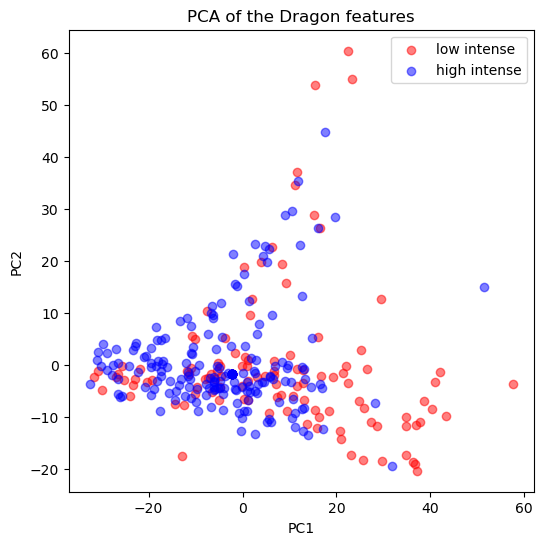

In [32]:
_, ax = plt.subplots(1, 1, figsize=(6, 6))

ax.scatter(mX_pca[vY == 0, 0], mX_pca[vY == 0, 1], c='red', label='low intense', alpha=0.5)
ax.scatter(mX_pca[vY == 1, 0], mX_pca[vY == 1, 1], c='blue', label='high intense', alpha=0.5)
ax.legend()
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title('PCA of the Dragon features')
plt.show()


In [ ]:
oKnn_clf = KNeighborsClassifier(n_neighbors=2, p=2)
oKnn_clf.fit(mX, vY)
oKnn_clf.score(mX, vY)


0.9519230769230769